In [44]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [45]:
X,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=42)

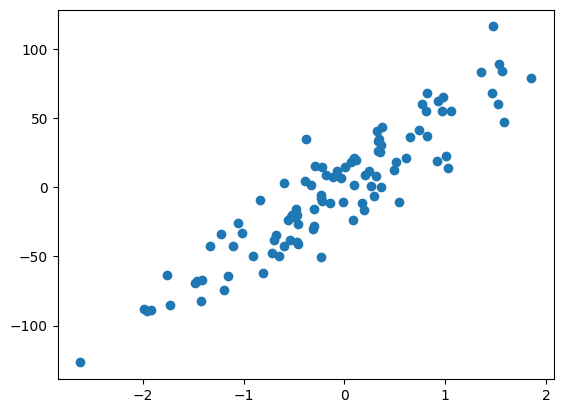

In [46]:
plt.scatter(X,y)

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge


In [48]:
lr=LinearRegression()
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [49]:
print(lr.coef_,lr.intercept_)

[47.13323967] 2.3302306410539453


In [50]:
rr=Ridge(alpha=10)

In [51]:
rr.fit(X,y)

,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [52]:
print(rr.coef_,rr.intercept_)

[41.9906212] 1.7961876226164746


In [53]:
rr1=Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_,rr1.intercept_)

[21.18627364] -0.3642714175995887


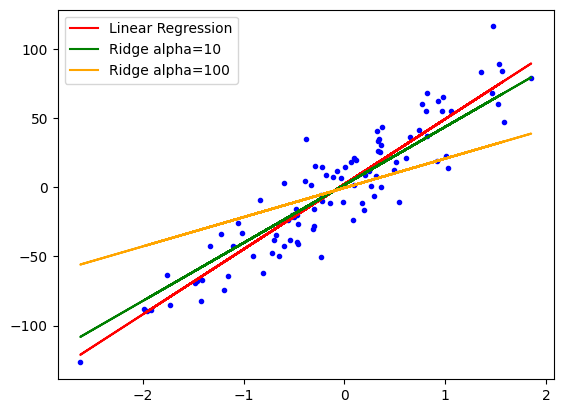

In [54]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='Linear Regression')
plt.plot(X,rr.predict(X),color='green',label='Ridge alpha=10')
plt.plot(X,rr1.predict(X),color='orange',label='Ridge alpha=100')
plt.legend()
plt.show()

In [55]:
class MeraRidge:
    def __init__(self,alpha=1.0):
        self.alpha=alpha
        self.coef_=None
        self.intercept_=None
    def fit(self,X,y):
        num=0
        den=0
        for i in range(X.shape[0]):
            num+=(y[i]-y.mean())*(X[i]-X.mean())
            den+=(X[i]-X.mean())**2
        den+=self.alpha
        self.coef_=num/den
        self.intercept_=y.mean()-self.coef_*X.mean()
    def predict(self,X):
        return self.coef_*X + self.intercept_

In [56]:
mr=MeraRidge(alpha=10)
mr.fit(X,y)

In [57]:
print(mr.coef_,mr.intercept_)

[41.9906212] [1.79618762]


In [58]:
mr=MeraRidge(alpha=100)
mr.fit(X,y)

In [59]:
print(mr.coef_,mr.intercept_)

[21.18627364] [-0.36427142]


In [60]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score

In [61]:
sX,y=load_diabetes(return_X_y=True)
X_train,X_test,y_train,y_test=train_test_split(sX,y,test_size=0.2,random_state=42)

In [62]:
from sklearn.linear_model import Ridge
reg=Ridge(alpha=0.1,solver='cholesky')

In [63]:
reg.fit(X_train,y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'cholesky'
,positive,False
,random_state,None


In [64]:
y_pred=reg.predict(X_test)

In [65]:
r2_score(y_test,y_pred)

0.46085219464119254

In [66]:
print(reg.coef_)

[  42.85566976 -205.49431899  505.08903304  317.0932049  -108.50026183
  -86.23673333 -190.36318008  151.70708637  392.28931896   79.9081772 ]


In [67]:
print(reg.intercept_)

151.45857456679613


In [68]:
class MeraRidge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.coef_=None
        self.intercept_=None
    def fit(self,X_train,y_train):
        X_train=np.insert(X_train,0,1,axis=1)
        I=np.identity(X_train.shape[1])
        result=np.linalg.inv(np.dot(X_train.T,X_train)+self.alpha*I).dot(X_train.T).dot(y_train)
        self.intercept_=result[0]
        self.coef_=result[1:]
    def predict(self,X_test):
        return np.dot(X_test,self.coef_)+self.intercept_



In [69]:
reg=MeraRidge(alpha=0.1)

In [70]:
reg.fit(X_train,y_train)

In [71]:
y_pred=reg.predict(X_test)

In [72]:
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.460791139668318
[  42.87709893 -205.49834268  505.10960427  317.09526097 -108.51126124
  -86.2562279  -190.37246178  151.70037599  392.29679967   79.93194581]
151.4155298431294
